In [7]:
import pandas as pd
import importlib
import data_audit

importlib.reload(data_audit)



df = pd.read_csv("restaurant_clf.csv")

# url: URL адрес на ресторанта в Restaurant GPT.
# address: Адрес на ресторанта.
# name: Име на ресторанта.
# online_order: Дали е налична опция за онлайн поръчка.
# book_table: Дали е налична опция за онлайн резервация на маса.
# votes: Общ брой гласове/оценки за ресторанта.
# phone: Телефонен номер на ресторанта.
# location: Кварталът, в който се намира ресторантът.
# rest_type: Тип на обекта.
# dish_liked: Списък с ястия, харесвани от клиентите.
# cuisines: Типове кухни, обслужвани от ресторанта.
# approx_cost(for two people): Приблизителна цена за хранене на двама души.
# reviews_list: Списък с ревюта и оценки от клиенти.
# menu_item: Списък с налични елементи от менюто.
# listed_in(type): Тип на хранене.
# listed_in(city): Зоната на града, в която е разположен ресторантът (обикновено по-голяма област от "location").
# rate: Общата агрегирана оценка на ресторанта.


In [8]:
# This if is put so that i can run all 
# cells without creating data audit every time
if False:

    data_audit.create_data_audit(df.drop(columns=['Unnamed: 0']), bar_chart_cols=['online_order', 'book_table', 'location', 'rest_type', 'cuisines', 'listed_in(type)', 'listed_in(city)'], no_chart_cols=['url', 'address', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)'], hue_column=None)

In [9]:
#Preprocessing data

from sklearn.preprocessing import OneHotEncoder

#Making rates to be numbers
df['rate_clean'] = (
    df['rate']
      .replace('-', pd.NA)     # "-" = missing
      .replace('NEW', pd.NA)   # "NEW" = missing rating
      .str.replace(' ', '', regex=False)
      .str.split('/')
      .str[0]
      .pipe(pd.to_numeric, errors='coerce')
)

print('preprocessed rates')

#creating target column
median_rate = df['rate_clean'].median()
df['above_median_rate'] = (df['rate_clean'] > median_rate).astype(int)

print('created target column')

#Mapping yes/no to 1/0
df['online_order'] = df['online_order'].map({'Yes': 1, 'No': 0})
df['book_table'] = df['book_table'].map({'Yes': 1, 'No': 0})

print('mapped online_order and book_table to 0/1')

# #One-hot encoding categorical features
# df_dummies = pd.get_dummies(df['location'], drop_first=True, dtype=int)
# df = pd.concat([df_dummies, df.drop(columns=['location'])], axis=1)

# print('one-hot encoded location')

# #One-hot encoding categorical features
# df_dummies = pd.get_dummies(df['name'], drop_first=True, dtype=int)
# df = pd.concat([df_dummies, df.drop(columns=['name'])], axis=1)

# print('one-hot encoded name')

# #One-hot encoding categorical features
# df_dummies = pd.get_dummies(df['phone'], drop_first=True, dtype=int)
# df = pd.concat([df_dummies, df.drop(columns=['phone'])], axis=1)

# print('one-hot encoded phone')

# #One-hot encoding categorical features
# df_dummies = pd.get_dummies(df['listed_in(type)'], drop_first=True, dtype=int)
# df = pd.concat([df_dummies, df.drop(columns=['listed_in(type)'])], axis=1)

# print('one-hot encoded listed_in(type)')

# #One-hot encoding categorical features
# df_dummies = pd.get_dummies(df['listed_in(city)'], drop_first=True, dtype=int)
# df = pd.concat([df_dummies, df.drop(columns=['listed_in(city)'])], axis=1)

# print('one-hot encoded listed_in(city)')

single_cat_cols = ['location', 'name', 'phone', 'listed_in(city)', 'listed_in(type)']

ohe = OneHotEncoder(drop='first', sparse_output=True, dtype=int)

ohe_matrix = ohe.fit_transform(df[single_cat_cols])

from scipy.sparse import csr_matrix
import numpy as np

def list_to_sparse(df_list, prefix=None):
    """
    Convert a Series of lists (multi-label) into a CSR sparse matrix.
    """
    # Create mapping: category → column index
    unique_values = sorted({item for sublist in df_list for item in sublist})
    col_index = {cat: i for i, cat in enumerate(unique_values)}

    # Build COO components
    rows = []
    cols = []
    data = []

    for row_idx, items in enumerate(df_list):
        for item in items:
            rows.append(row_idx)
            cols.append(col_index[item])
            data.append(1)

    # Convert to sparse CSR matrix
    mat = csr_matrix((data, (rows, cols)),
                     shape=(len(df_list), len(unique_values)),
                     dtype=int)
    return pd.DataFrame.sparse.from_spmatrix(mat, columns=unique_values)


rest_type = list_to_sparse(df, 'rest_type')

print('one-hot encoded rest_type')

dish_liked = list_to_sparse(df, 'dish_liked')

print('one-hot encoded dish_liked')

cuisines = list_to_sparse(df, 'cuisines')

print('one-hot encoded cuisines')

menu_item = list_to_sparse(df, 'menu_item')

print('one-hot encoded menu_item')

preprocessed rates
created target column
mapped online_order and book_table to 0/1
one-hot encoded rest_type
one-hot encoded dish_liked
one-hot encoded cuisines
one-hot encoded menu_item


In [10]:
df = df.drop(columns=['Unnamed: 0'])
print(df.columns)

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)', 'rate_clean',
       'above_median_rate'],
      dtype='object')


In [11]:
y = df['above_median_rate']

ohe_df = pd.DataFrame.sparse.from_spmatrix(
    ohe_matrix,
    columns=ohe.get_feature_names_out(single_cat_cols)
)

df_sparse_all = pd.concat([
    ohe_df,
    rest_type,
    dish_liked,
    cuisines,
    menu_item
], axis=1)


X = pd.concat([
    df_sparse_all,
    df[['online_order', 'book_table', 'votes']]
], axis=1)



In [12]:
print(X.columns.size)

23964


The columns are too many, that's why we will do TruncatedSVD 
so that we can get what are the useful columns and we are not
using PCA, because it's not optimized for sparse matrices.

In [13]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=1)
X_reduced = svd.fit_transform(X)

print(X_reduced.shape[0])

/home/bryan/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


51717


In [14]:
print(X_reduced.shape[1])

1


In [15]:
explained = svd.explained_variance_ratio_.sum()
print("Total variance preserved:", explained)

Total variance preserved: 0.9999925458181222


We are preserving 99.9993% of the variance, so we can be sure that we are preserving most of the information. I also tried doing it with 100
dimensions and it preserved 99.9997%, with 10 and got 99.9994%, with 5 and got 99.9994% and with 2 and got 99.9993%.

In [16]:
import classification
importlib.reload(classification)

# STOP — do not run unless removed
if False:
    X_reduced = pd.DataFrame(X_reduced)
    classification.classify(X_options=[X_reduced], y=y, filename='./model_report.xlsx', diagrams='./diagrams', append=False)


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

reviews_list = df['reviews_list']

vectorizer = TfidfVectorizer(input='content')
reviews_tfidf = vectorizer.fit_transform(reviews_list)

In [18]:
print(reviews_tfidf.shape)

(51717, 66926)


In [19]:
from sklearn.decomposition import TruncatedSVD

model = TruncatedSVD(n_components=100)
reviews_tfidf_reduced = model.fit_transform(reviews_tfidf)

print("Variance per component:")
print(svd.explained_variance_ratio_)

print("\nTotal variance preserved:")
print(svd.explained_variance_ratio_.sum())

Variance per component:
[0.99999255]

Total variance preserved:
0.9999925458181222


We see that most of the variance is preserved but let's try to use even less components.

In [20]:
model = TruncatedSVD(n_components=5)
reviews_tfidf_reduced = model.fit_transform(reviews_tfidf)

print("Variance per component:")
print(svd.explained_variance_ratio_)

print("\nTotal variance preserved:")
print(svd.explained_variance_ratio_.sum())

Variance per component:
[0.99999255]

Total variance preserved:
0.9999925458181222


In [21]:
model = TruncatedSVD(n_components=2)
reviews_tfidf_reduced = model.fit_transform(reviews_tfidf)

print("Variance per component:")
print(svd.explained_variance_ratio_)

print("\nTotal variance preserved:")
print(svd.explained_variance_ratio_.sum())

Variance per component:
[0.99999255]

Total variance preserved:
0.9999925458181222


So, we will use only this two dimensions if they preserve 99.999% of variance, and also they will be perfect for plotting.

In [22]:
import openpyxl
import clusterization

importlib.reload(clusterization)

if False:
    filename = './model_report_review_list.xlsx'
    diagrams_folder_path = './diagrams'

    wb = openpyxl.Workbook()
    wb.create_sheet('ModelReport')
    ws = wb['ModelReport']

    ws.append(['Model', 'Scaling/PCA/t-SNE/TruncatedSVD', 'Number of variables','Hyperparams', 'Inertia', 'Silhouette', 'Silhouette Increase from base model %', 'Silhouette for test data', 'Silhouette for test data increase %','Scatter plot train', 'Dendrogram', 'Scatter plot test', 'PCA variance', 'Cross-Tabulation'])

    clusterization.base_model(reviews_tfidf_reduced, ws)

    model_options = [
        # 'agglomerative',
        # 'dbscan',
        'hdbscan'
    ]

    data_preprocessing = [
        {'scaling':False,
            'pca':False,
            'tsne': False,
            'truncatedsvd':False},
    ]

    n_components = [1]
    print(f'{n_components=}')

    cluster_sizes = [2, 1000, 5000]
    # cluster_sizes = [2]
    reviews_clusterization_models = []

    for name in model_options:
        for preprocessing in data_preprocessing:
            for n_component in n_components:
                for cluster_size in cluster_sizes:
                    scaling = preprocessing['scaling']
                    pca = preprocessing['pca']
                    tsne = preprocessing['tsne']
                    truncatedsvd = preprocessing['truncatedsvd']

                    args = {'params':{'hdbscan__min_cluster_size': [cluster_size]}}
                    print(f'Training on cluster size:{cluster_size}')
                    
                    reviews_clusterization_models.append(clusterization.clusterize(X=reviews_tfidf_reduced, args=args,real_labels=df['above_median_rate'], name=f'{name}{cluster_size}', n_features=n_component, scaling=scaling, pca=pca, tsne=tsne, truncatedsvd=truncatedsvd, ws=ws, clusterization_distance=1.41))

    wb.save(filename)

In [23]:
if False:
    for model in reviews_clusterization_models:
        hdb = model.named_steps["hdbscan"]

        print('INFORMATION PRINT:')

        labels = hdb.labels_

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        print("Number of clusters:", n_clusters)

        n_noise = np.sum(labels == -1)
        print("Noise points:", n_noise)

        # Count only non-noise clusters
        valid_labels = labels[labels >= 0]
        cluster_sizes = np.bincount(valid_labels)

        # Get indices of clusters sorted by size (largest first)
        top_k = 20
        largest_clusters_idx = np.argsort(cluster_sizes)[::-1][:top_k]

        # Get corresponding sizes
        largest_clusters_sizes = cluster_sizes[largest_clusters_idx]

        for rank, (cid, size) in enumerate(zip(largest_clusters_idx, largest_clusters_sizes), 1):
            print(f"{rank}. Cluster {cid}: {size} points")





Ok so we got a general idea of what the data looks like, now I will train classification models based on this data to try and predict if the rating will be above average only by looking at the reviews list and after that i will do it by using both the other data and review list.

In [24]:
if False:
    classification.classify(X_options=[pd.DataFrame(reviews_tfidf_reduced)], y=y, filename='./model_report_classification_only_review_list.xlsx', diagrams='./diagrams', append=False)

Now let's use all of the available data.

In [67]:
X_reduced_df = pd.DataFrame(X_reduced)
reviews_tfidf_reduced_df = pd.DataFrame(reviews_tfidf_reduced)

X = pd.concat([X_reduced_df, reviews_tfidf_reduced_df], axis=1)
X.columns = X.columns = [i for i, _ in enumerate(X.columns)]


if False:
    classification.classify(X_options=[X], y=y, filename='./model_report_using_all_data.xlsx', diagrams='./diagrams', append=False)

The best model trained can be found in the model_report_using_all_data.xlsx file and as it's shown it achieves a 0.9 f1 score.

In [68]:
print(X.columns)

Index([0, 1, 2], dtype='int64')


In [77]:
import classification
importlib.reload(classification)

from sklearn.base import BaseEstimator, TransformerMixin

class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # If X is a DataFrame → select by column names
        if hasattr(X, 'loc'):
            return X[self.columns]
        
        # If X is a NumPy array → select by column indices
        else:
            return X[:, self.columns]

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

best_model_on_data_without_reviews, _ = classification.train_and_test_model(X=X, y=y, export_to_file=False, name='cart', ws=None, pipeline_steps=[('select', ColumnSelector([0]))] )
best_model_on_only_reviews, _ = classification.train_and_test_model(X=X, y=y, export_to_file=False, name='knn', ws=None, pipeline_steps=[('select', ColumnSelector([1, 2]))])



(51717, 3)
(51717,)


In [78]:
print(best_model_on_only_reviews)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('select',
                                              ColumnSelector(columns=[1, 2])),
                                             ('imp',
                                              SimpleImputer(strategy='median')),
                                             ('scaler', StandardScaler()),
                                             ('knn', KNeighborsClassifier())]),
                   param_distributions={'knn__n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])},
                   return_train_score=True, scoring='f1')


In [79]:
print(best_model_on_data_without_reviews)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('select',
                                              ColumnSelector(columns=[0])),
                                             ('imp',
                                              SimpleImputer(strategy='median')),
                                             ('scaler', StandardScaler()),
                                             ('cart',
                                              DecisionTreeClassifier())]),
                   param_distributions={'cart__criterion': ['gini', 'entropy'],
                                        'cart__max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 1...
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]),
                                        'car

In [80]:
print(X.shape)
print(y.shape)

(51717, 3)
(51717,)


(36201, 3)
(36201,)


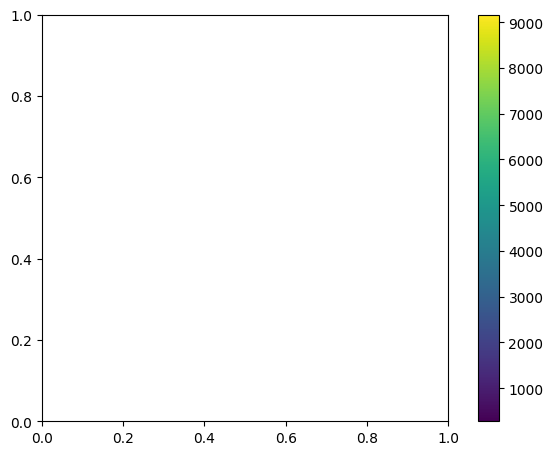

In [85]:
importlib.reload(classification)

wb = openpyxl.Workbook()
wb.create_sheet('ModelReport')
ws = wb['ModelReport']

ws.append(['Model', 'Scaling', 'Number of variables','Hyperparams', "Precision", "Precision increase from base model (in %)", "Recall", "Recall increase from base model (in %)", "F1 Score", "F1 score increase from base model (in %)", "Confusion matrix", "Comments"])

args = {'models':[('est1',best_model_on_data_without_reviews), ('est2',best_model_on_only_reviews)] , 'tune':False}

ensemble_model = classification.train_and_test_model(X=X, y=y, export_to_file=True, name='ensemble', ws=ws, args=args, base_model_precision=0.391438018446546, base_model_recall=1, base_model_f1=0.562638095635136)

wb.save('model_report_ensemble.xlsx')